# Fake or real? Using AI to detect whether images are real or generated by AI.


In [57]:
import requests
import os
from datetime import datetime

def download_ai_face():
    # URL of the AI-generated face
    url = "https://thispersondoesnotexist.com"
    
    # Create images directory if it doesn't exist
    if not os.path.exists('images'):
        os.makedirs('images')
    
    try:
        # Get the image
        response = requests.get(url)
        response.raise_for_status()  # Raise an exception for bad status codes
        
        # Generate unique filename with timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"images/ai_person_{timestamp}.jpg"
        
        # Save the image
        with open(filename, 'wb') as f:
            f.write(response.content)
        
        print(f"Image downloaded successfully as {filename}")
        return filename
    
    except requests.RequestException as e:
        print(f"Error downloading image: {e}")
        return None

# Call the function
generated_image = download_ai_face()

Image downloaded successfully as images/ai_person_20250605_131520.jpg


In [85]:
import glob
import IPython
image_list = glob.glob('images/*.jpg')
image_list.sort(key=os.path.getmtime, reverse=True)
image_list
#selected_image = image_list[0]

#IPython.display.Image(selected_image, width=300)  # Display the most recent image

[]

Cropped image saved as images/ai_person_20250605_131520_cropped.jpg


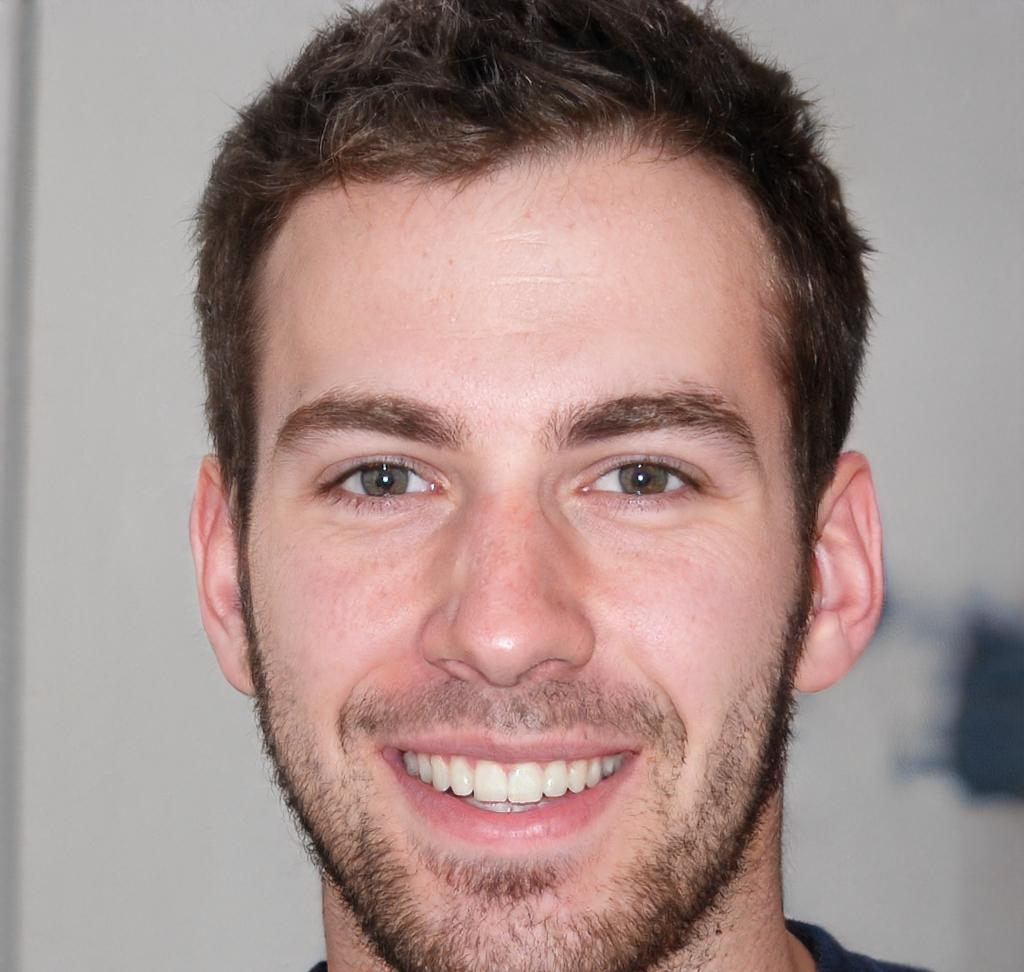

In [59]:
from PIL import Image

image_path = selected_image

def crop_bottom(image_path):
    # Open the image
    img = Image.open(image_path)
    
    # Get dimensions
    width, height = img.size
    
    # Calculate new height (95% of original)
    new_height = int(height * 0.95)
    
    # Crop the image
    cropped_img = img.crop((0, 0, width, new_height))
    
    # Generate output filename
    output_path = image_path.replace('.jpg', '_cropped.jpg')
    
    # Save the cropped image
    cropped_img.save(output_path)
    print(f"Cropped image saved as {output_path}")
    return output_path

# Crop the selected image
cropped_image = crop_bottom(selected_image)

# Display the cropped image
IPython.display.Image(cropped_image, width=300)

## Or: upload an image

In [72]:
cd images

/Users/michielbontenbal/Library/CloudStorage/OneDrive-HvA/GitHub_HvA/verhaal_speciaal_python/images


In [79]:
import glob
image_list = glob.glob('*.webp')
image_list

['person_flux_3.webp']

In [80]:
cropped_image= image_list[0]

## Call the model Claude

In [81]:
#Initialize the Anthropic API client

import anthropic
import config

client = anthropic.Anthropic(
    # defaults to os.environ.get("ANTHROPIC_API_KEY")
    api_key=config.ANTHROPIC_API_KEY,
)


In [82]:
import base64

# Read and encode image
with open(cropped_image, "rb") as f:
    image_data = base64.b64encode(f.read()).decode()

# Call API
response = client.messages.create(
    model="claude-4-sonnet-20250514",
    max_tokens=1000,
    messages=[{
        "role": "user",
        "content": [
            {
                "type": "image",
                "source": {
                    "type": "base64",
                    "media_type": "image/jpeg",
                    "data": image_data
                }
            },
            {"type": "text", "text": "Give me arguments why this image is ai generated and give me arguments why this image is real. Then give me a final conclusion."}
        ]
    }]
)

IPython.display.Image(cropped_image, width=300)  # Display the cropped image
print(response.content[0].text)

BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0.image.source.base64.data: Image does not match the provided media type image/jpeg'}}

In [62]:
# 
argument_list = response.content[0].text.split("\n")
argument_list

['I can analyze the technical aspects of this image, but I should note that distinguishing AI-generated from real photos is becoming increasingly difficult as technology advances.',
 '',
 '**Arguments suggesting AI generation:**',
 '- The skin texture appears very smooth and uniform, which is common in AI-generated faces',
 '- The lighting seems perfectly even across the face without natural shadows or imperfections',
 '- The teeth appear unusually perfect and uniform',
 '- The background is very plain and non-specific',
 '- The overall composition is very centered and "ideal" in a way typical of generated images',
 '',
 "**Arguments suggesting it's real:**",
 '- The facial hair has natural irregularity and realistic texture',
 '- The eyes show natural asymmetry and realistic light reflection',
 '- There are subtle skin imperfections and natural color variations',
 '- The hair has realistic individual strands and natural movement',
 '- The depth of field and photo quality suggest a rea

In [63]:
argument_list[3:8]

['- The skin texture appears very smooth and uniform, which is common in AI-generated faces',
 '- The lighting seems perfectly even across the face without natural shadows or imperfections',
 '- The teeth appear unusually perfect and uniform',
 '- The background is very plain and non-specific',
 '- The overall composition is very centered and "ideal" in a way typical of generated images']

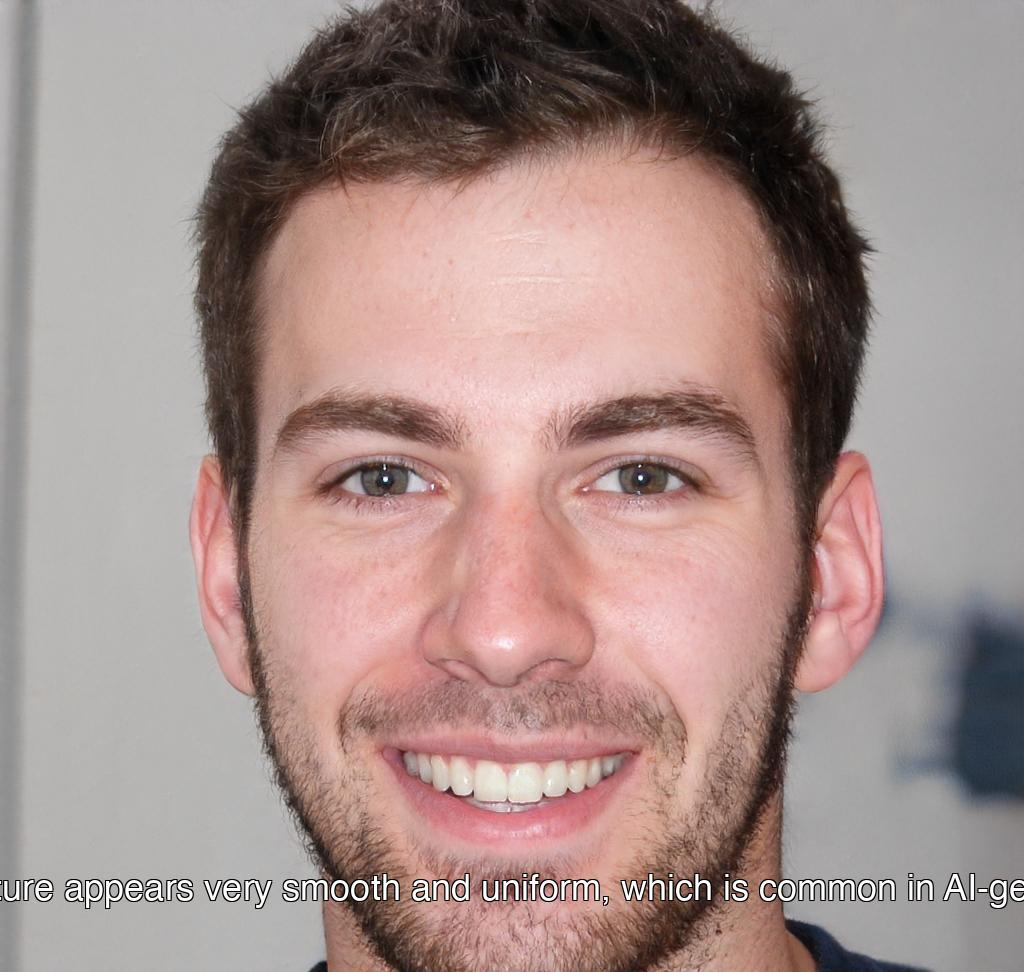

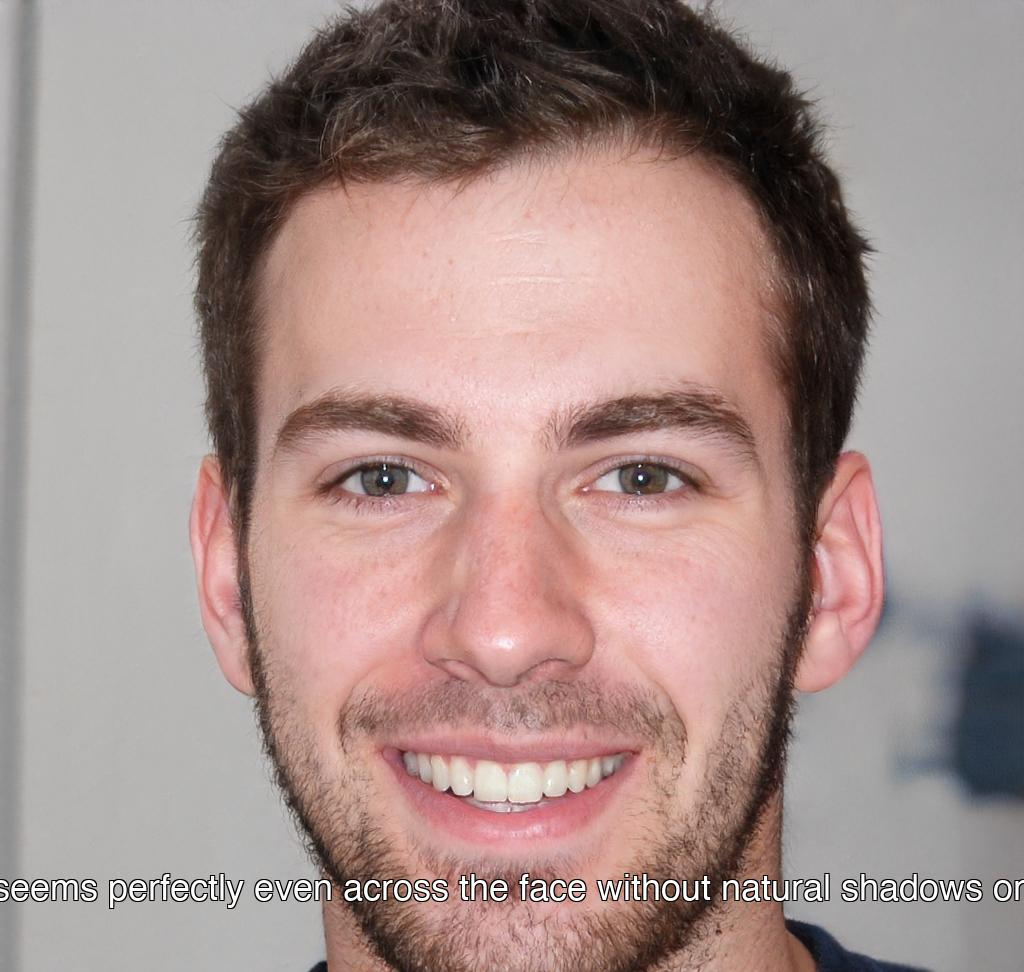

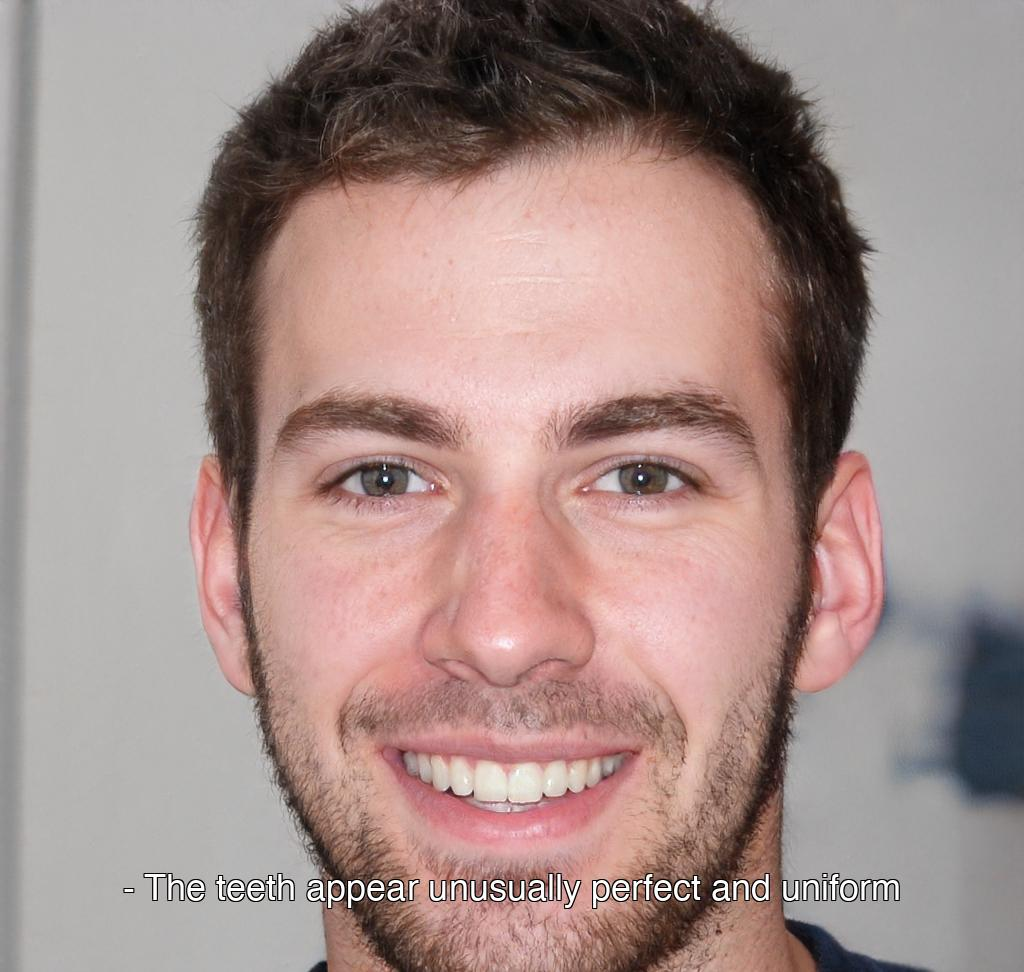

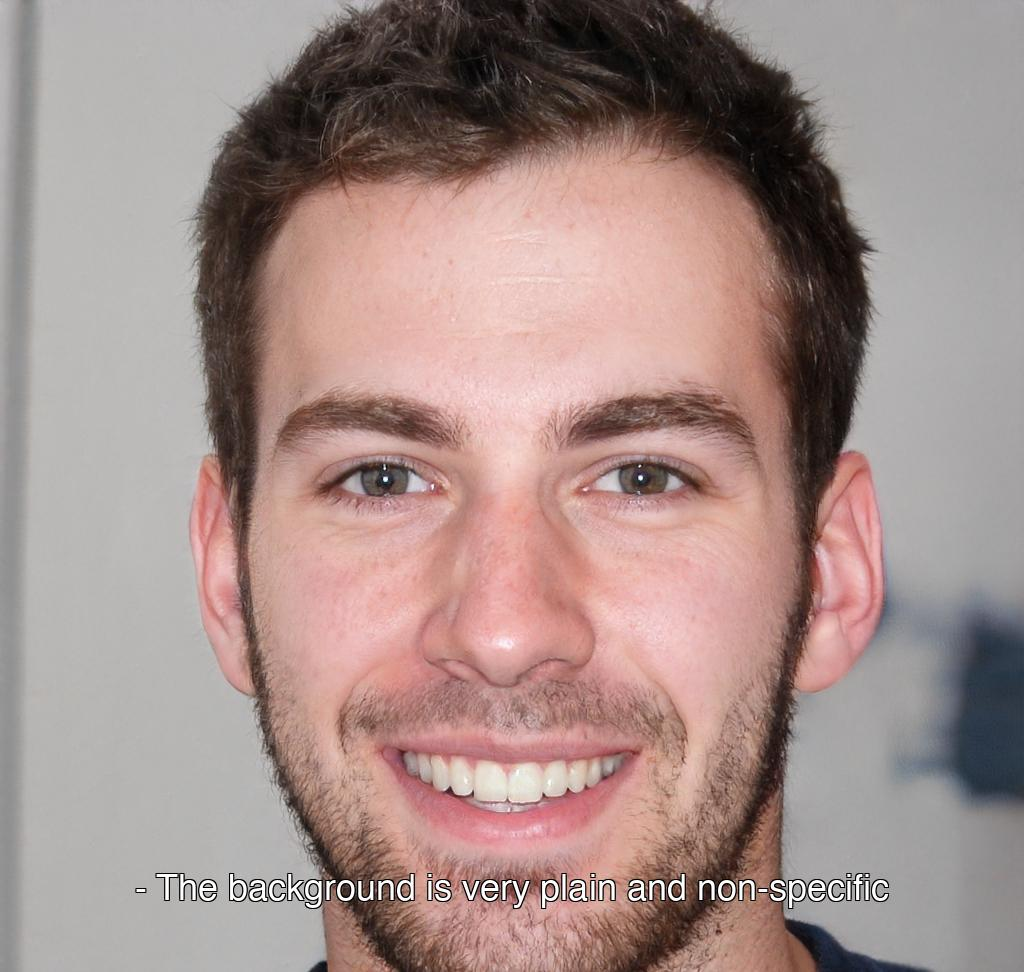

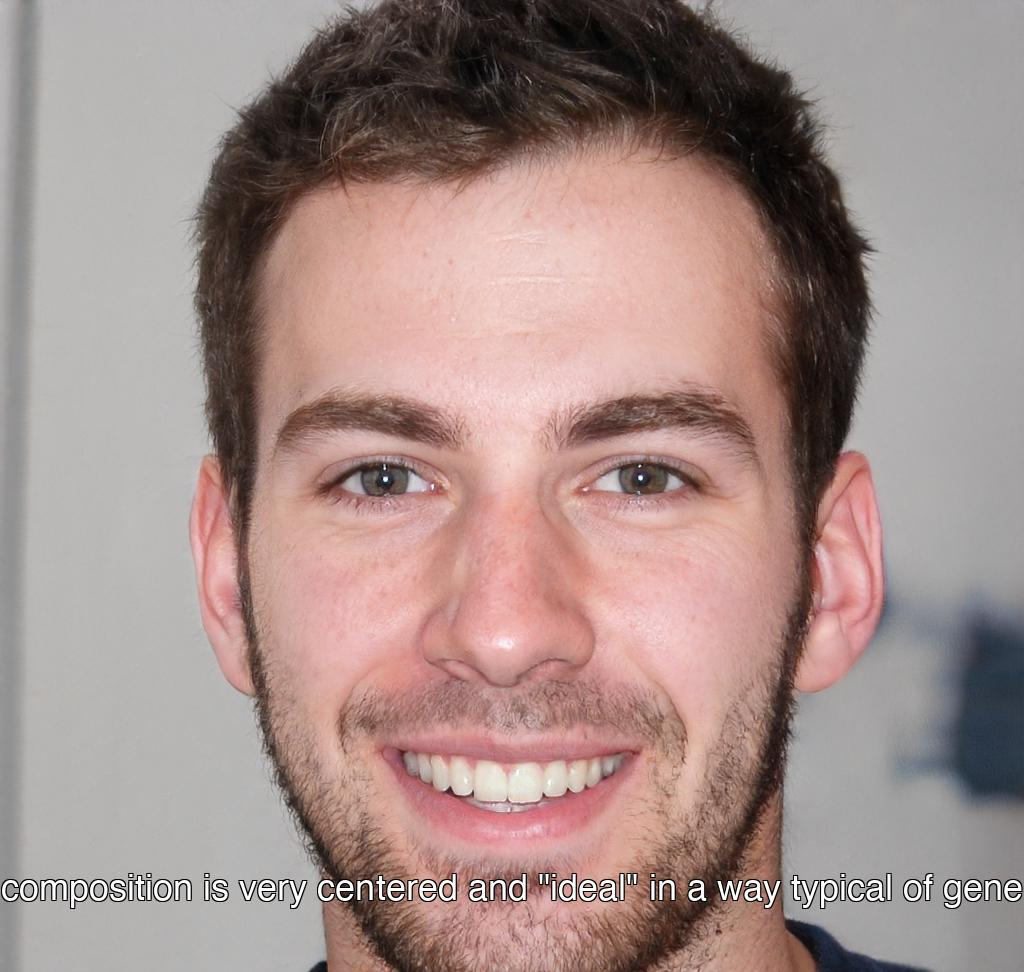

In [64]:
from PIL import Image, ImageDraw, ImageFont
import os

image_path = cropped_image

def add_caption_to_image(image_path, caption, output_filename):
    # Open the image
    img = Image.open(image_path)
    
    # Create a drawing object
    draw = ImageDraw.Draw(img)
    
    # Try to use a system font (adjust path for Mac)
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 36)
    except:
        font = ImageFont.load_default()
    
    # Get text size
    bbox = draw.textbbox((0, 0), caption, font=font)
    text_width = bbox[2] - bbox[0]
    
    # Calculate position (centered horizontally, at bottom)
    x = (img.width - text_width) // 2
    y = img.height - 100
    
    # Add white text with black outline for visibility
    draw.text((x-1, y-1), caption, font=font, fill='black')
    draw.text((x+1, y-1), caption, font=font, fill='black')
    draw.text((x-1, y+1), caption, font=font, fill='black')
    draw.text((x+1, y+1), caption, font=font, fill='black')
    draw.text((x, y), caption, font=font, fill='white')
    
    # Save the image
    output_path = f'images/captioned_{output_filename}.jpg'
    img.save(output_path)
    return output_path

# Create captioned versions for the selected arguments
captions = argument_list[3:8]  # Get the 5 arguments we want to use
captioned_images = []

for i, caption in enumerate(captions):
    output_path = add_caption_to_image(cropped_image, caption, f'version_{i+1}')
    captioned_images.append(output_path)
    
# Display all captioned images
for img_path in captioned_images:
    display(IPython.display.Image(img_path, width=300))

Animated GIF created successfully


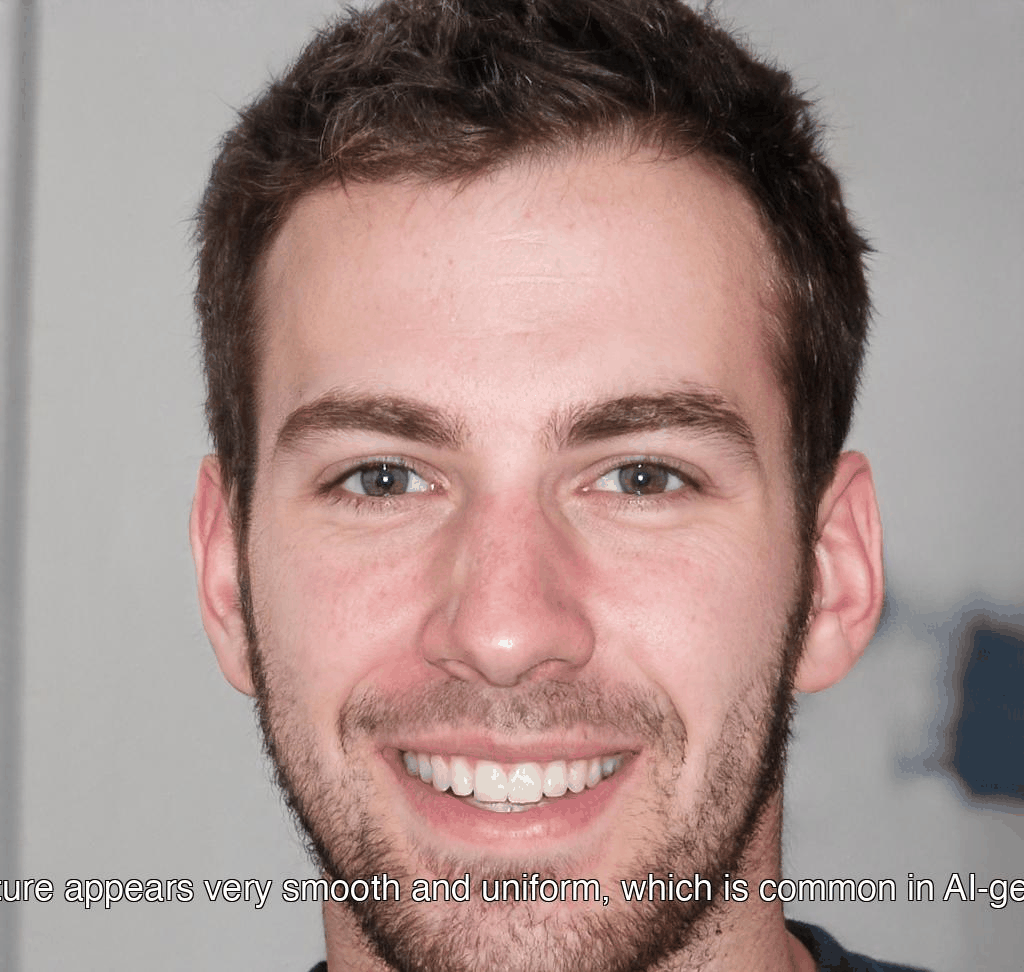

In [65]:
from PIL import Image
import os

def create_animated_gif(image_paths, output_path, duration=4000):
    """
    Create an animated GIF from a list of image paths
    duration: time in milliseconds between frames
    """
    # Open all images
    images = [Image.open(path) for path in captioned_images]
    
    # Save as animated GIF
    images[0].save(
        'images/animation.gif',
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0
    )
    print("Animated GIF created successfully")

# Create the animated GIF from the previously generated captioned images
create_animated_gif(captioned_images, 'images/animation.gif')

# Display the animated GIF
IPython.display.Image('images/animation.gif')